# MASTER'S THESIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import astropy

In [2]:
from astropy.table import Table

data_path = '../data/galah_catalog/'
df_galah = Table.read(f"{data_path}galah_dr4_allstar_240705.fits",format="fits").to_pandas()
column = df_galah.columns
#print(column)


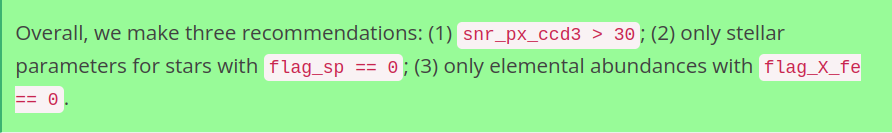

In [3]:
##Applying the cuts to the data suugested by Galah documentation 
df_galah = df_galah[df_galah['snr_px_ccd3'] > 30] #Average SNR per pixel in the CCD3 (green) spectrum > 30

df_galah = df_galah[df_galah['flag_sp'] == 0] # reliable spectroscopic analysis--> Major spectrscopic quality


#df_galah = df_galah[df_galah['flag_li_fe'] == 0] --> fails


[print(key) for key in df_galah.keys() if ("li" in key.lower() or ("flag" in key.lower() and "li" in key.lower()))]

nn_li_fe
nn_e_li_fe
nn_flag_li_fe
ew_li
e_ew_li_low
e_ew_li_upp
a_li
a_li_upp_lim
e_a_li_low
e_a_li_upp
e_a_li_teff
flag_a_li


[None, None, None, None, None, None, None, None, None, None, None, None]

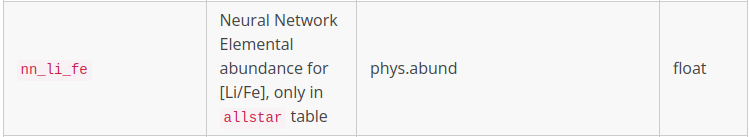

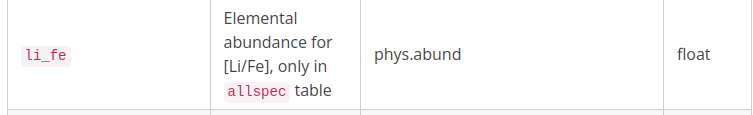

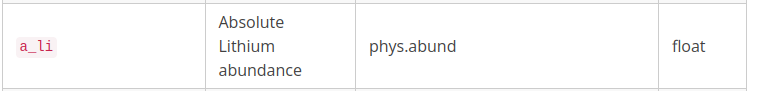

In [ ]:
# flags associated with lithium abundance and lithium to iron ratio

df_galah = df_galah[df_galah['nn_flag_li_fe'] == 0] # reliable lithium to iron ratio
df_galah = df_galah[df_galah['flag_a_li'] == 0] # reliable lithium abundance

nn_li_fe = df_galah['nn_li_fe'] #Lithium to iron ratio
a_li = df_galah['a_li'] #Lithium abundance

## More flags

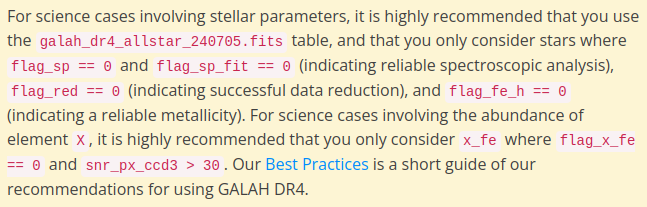

In [4]:
df_galah = df_galah[df_galah['flag_sp_fit'] == 0] # reliable spectroscopic analysis --> major spectriscopy fitting 

df_galah = df_galah[df_galah['flag_red'] == 0] # reliable reduction --> Quality bitmask flag of reduction pipeline

df_galah = df_galah[df_galah['flag_fe_h'] == 0] #reliable metallicity 




In [ ]:
# Some stellar parameters
mass = df_galah['mass']
age = df_galah['age']
lbol = df_galah['lbol']
r_med = df_galah['r_med']
sobject_id = df_galah['sobject_id']
teff = df_galah['teff']
logg = df_galah['logg'] 
v_sini = df_galah['vsini']




## 3D NLTE li Abundances

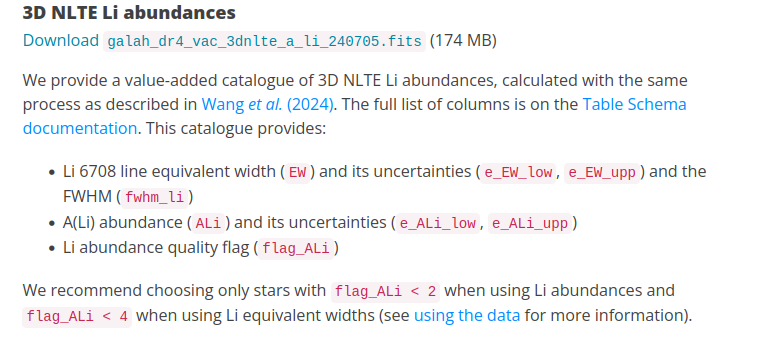

In [12]:
data_path = '../data/galah_catalog/'
df_galah_3dnlte = Table.read(f"{data_path}galah_dr4_vac_3dnlte_a_li_240705.fits",format="fits").to_pandas()
column = df_galah_3dnlte.columns
print(column)

Index(['sobject_id', 'tmass_id', 'teff', 'e_teff', 'logg', 'e_logg', 'fe_h',
       'e_fe_h', 'EW', 'e_EW_low', 'e_EW_upp', 'e_EW_norris', 'ALi',
       'ALi_upp_lim', 'e_ALi_low', 'e_ALi_upp', 'e_ALi_teff', 'minchisq',
       'flag_sp', 'flag_fe_h', 'flag_ALi', 'fwhm_li', 'rv', 'snr', 'CN1', 'Fe',
       'CN2', 'V/Ce', 'Quest1', 'Quest2'],
      dtype='object')


In [15]:
# Flags
df_galah_3dnlte = df_galah_3dnlte[df_galah_3dnlte['flag_ALi'] == 0] # reliable lithium to iron ratio
df_galah_3dnlte = df_galah_3dnlte[df_galah_3dnlte['flag_fe_h'] == 0] # reliable lithium to iron ratio
df_galah_3dnlte = df_galah_3dnlte[df_galah_3dnlte['flag_sp'] == 0] # reliable lithium to iron ratio

# Lit from 3D NLTE

teff_3dnlte = df_galah_3dnlte['teff']
logg_3dnlte = df_galah_3dnlte['logg']
Ali_3dnlte = df_galah_3dnlte['ALi']



## Plot temp against a_Li

## Plot a_li and metallicity

## Plot a_li and 